In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt


In [3]:
datos_penguins = pd.read_csv('../../data/raw/penguins.csv')

In [4]:
datos_penguins.shape

(344, 7)

Tenemos 344 filas, y 7 caracteristicas

In [5]:
datos_penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


Tenemos 7 categorias, 4 numericas y 3 categoricas.

In [6]:
datos_penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Tenemos pocos nulos, los cuales, para este analisis, los voy a eliminar, y no los voy a tener en cuenta.

In [7]:
datos_penguins = datos_penguins.dropna()

#### ¿Que es este dataset? 

Palmerpenguins sale en 2020, como alternativa de "dataset de juguete" a iris.
Son datos recolectados entre 2007 y 2009 (Columna existente, la cual falta en este dataset), por la Dra. Kristen Gorman, el cual contiene datos acerca de los datos de 344 pinguinos, tomados de 3 islas del archipielago Palmer, en la Antartida.

Son datos que hablan de:

In [8]:
datos_penguins.species.unique()

<ArrowStringArray>
['Adelie', 'Chinstrap', 'Gentoo']
Length: 3, dtype: str

- Las 3 especies que se estudiaron en el dataset: En el mundo hay 18, y 7 de ellas viven en la antartida (https://www.asoc.org/learn/antarctic-penguins-directory/)

In [9]:
categoricas = datos_penguins.select_dtypes(include=['object', 'category'])
categoricas.value_counts()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_5448\303131875.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = datos_penguins.select_dtypes(include=['object', 'category'])


species    island     sex   
Gentoo     Biscoe     Male      61
                      Female    58
Chinstrap  Dream      Female    34
                      Male      34
Adelie     Dream      Male      28
                      Female    27
           Torgersen  Female    24
                      Male      23
           Biscoe     Female    22
                      Male      22
Name: count, dtype: int64

In [10]:
datos_penguins.island.unique()

<ArrowStringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str

- Estas son las 3 islas de las cuales se recabo informacion.

Ademas, vemos caracteristicas fisicas de los pinguinos
- Estan las columnas bill_lenght y bill_depth, que refieren al pico de los pinguinos

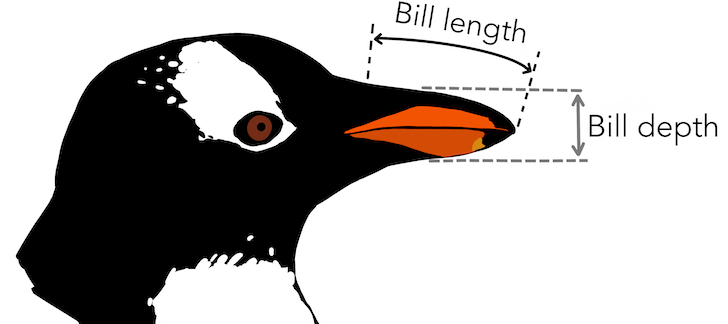

- La columna flipper_lengtH, que refiere al largo de la aleta

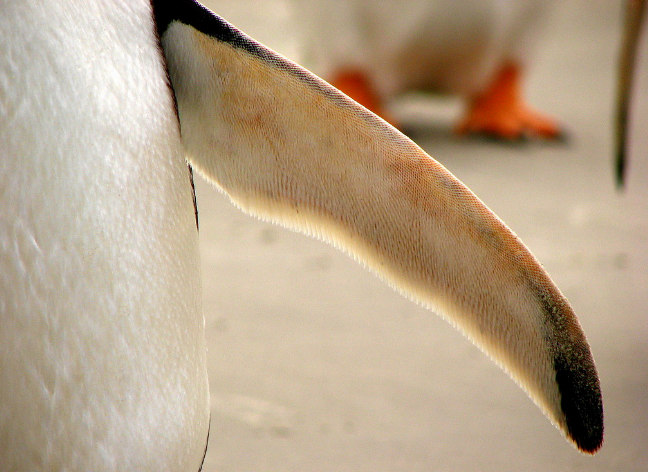

- y por ultimo, el peso del pinguino, y su sexo

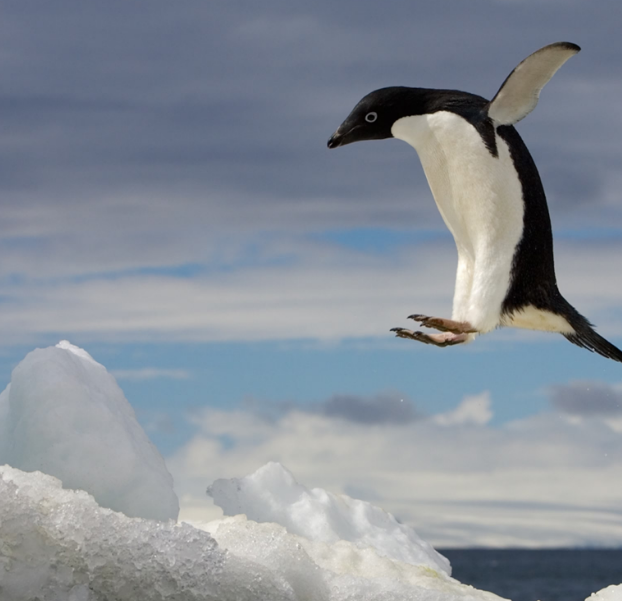

In [11]:
datos_penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


Dando un primer vistaso, vemos que para las variables numericas, las medias y las medianas, coinciden bastante, por lo que las variables son simetricas. Veamos el skew y la kurtosis!

In [12]:
from scipy.stats import skew, kurtosis

datos_numericos = datos_penguins.select_dtypes(include=['float64', 'int64'])
stats_list = []
for col in datos_numericos.columns:
    stats_list.append({
        'Variable': col,
        'Asimetría (Skewness)': skew(datos_numericos[col]),
        'Curtosis (Kurtosis)': kurtosis(datos_numericos[col])
    })

df_stats = pd.DataFrame(stats_list)
display(df_stats)

,Variable,Asimetría (Skewness),Curtosis (Kurtosis)
0,bill_length_mm,0.045136,-0.888173
1,bill_depth_mm,-0.149045,-0.896587
2,flipper_length_mm,0.358524,-0.964833
3,body_mass_g,0.470116,-0.740486


Vemos que el unico analisis que coincide con lo que preveimos, es el del largo del pico, y veo que el peso tiene bastaaaante asimetria.

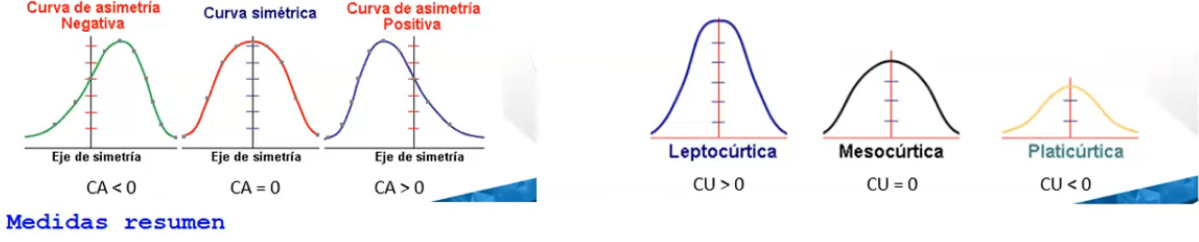

Grafiquemos a ver que onda

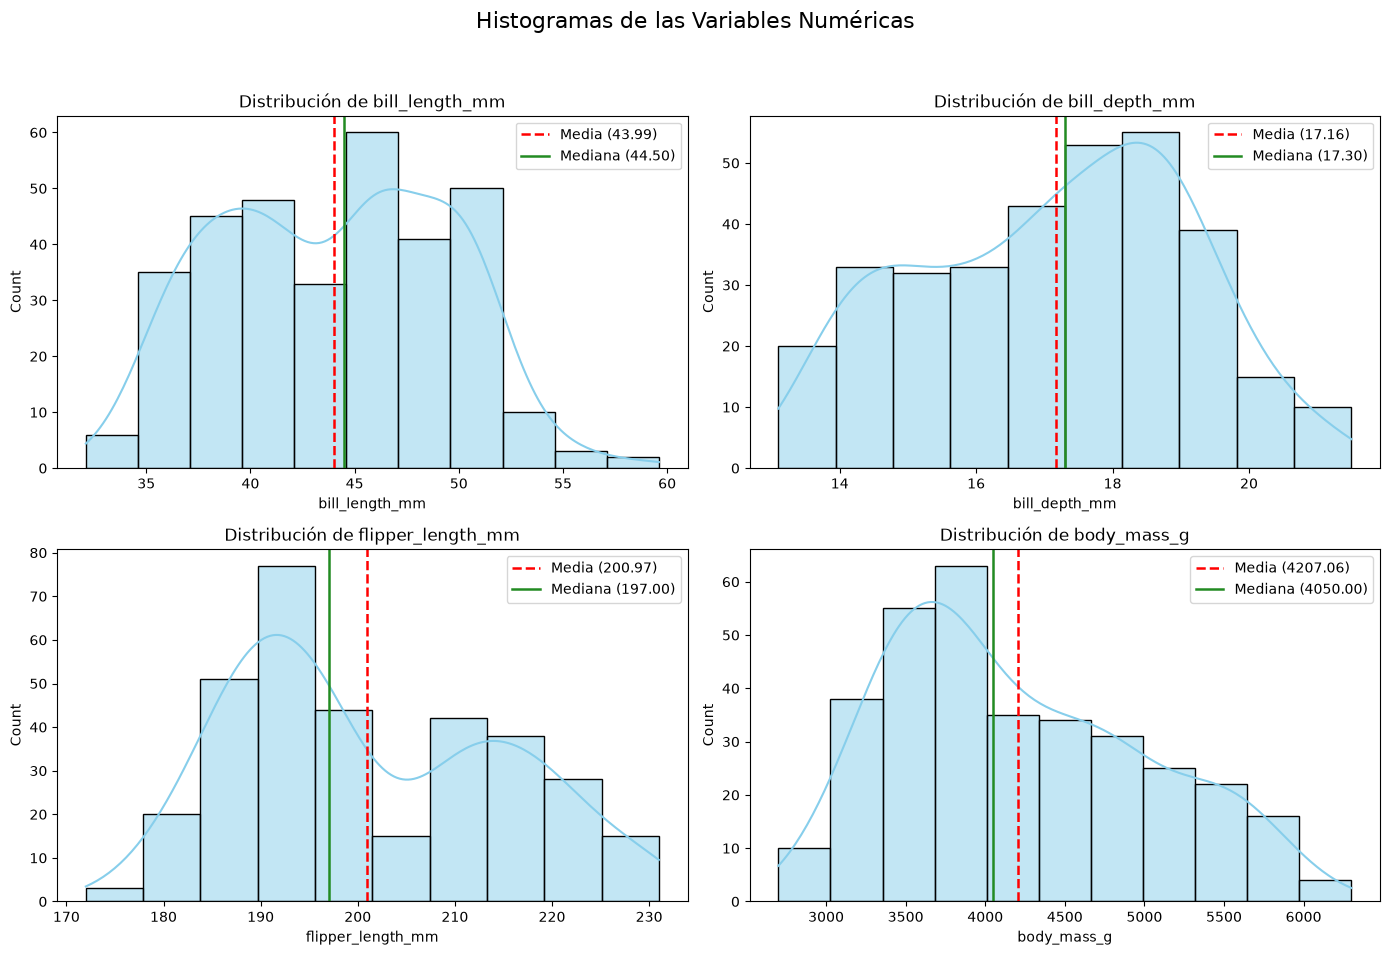

In [13]:
# Seleccionar las columnas numéricas
columnas_numericas = datos_penguins.select_dtypes(include=['float64', 'int64']).columns

# Configuración de los histogramas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Histogramas de las Variables Numéricas', fontsize=16)

for i, col in enumerate(columnas_numericas):
    ax = axes[i // 2, i % 2]
    
    # Histograma con KDE
    sns.histplot(datos_penguins[col], kde=True, ax=ax, color='skyblue')
    
    # Cálculo de métricas
    media = datos_penguins[col].mean()
    mediana = datos_penguins[col].median()
    
    # Líneas verticales
    ax.axvline(media, color='red', linestyle='--', linewidth=1.8, label=f'Media ({media:.2f})')
    ax.axvline(mediana, color='forestgreen', linestyle='-', linewidth=1.8, label=f'Mediana ({mediana:.2f})')
    
    ax.set_title(f'Distribución de {col}')
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Vemos que nada es gaussiano si lo analizamos variable a variable! Vemos en el peso una cola larga bastante pronunciada hacia pesos grandes.
Como vimos para bill_depth, hay un poco de asimetria negativa.
Y para los casos de bill_length y flippler_lenght, hay algo de bimodalidad, lo que hace que la media quede en donde no hay demasiados datos, por lo que sin analisis previo, podriamos haber tomado la media como "el peso mas probable", y luego haber medido muy pocos pinguinos con este valor


In [14]:
datos_penguins.mode()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Biscoe,41.1,17.0,190.0,3800.0,Male


Esto justamente nos da una nocion mas fundamental del dataset, pero sigue sin ser muy abarcativo.
Al ser la moda, podriamos decir que lo normal seria, que si tomo una muestra del dataset, lo normal es obtener una instancia de estas caracteristicas, pero esto es bastante mentiroso:

Probablemente, si tomamos un pinguino de la especie adelie, no sabemos si estos residen en esta isla, si la especie es mas chica que las demas, etcetera. Pero analizaremos mas esto en el ejercicio 2

Hagamos un analisis con boxplots, a primera vista, viendo los histogramas, no se nota que haya algun valor por fuera de lo normal.

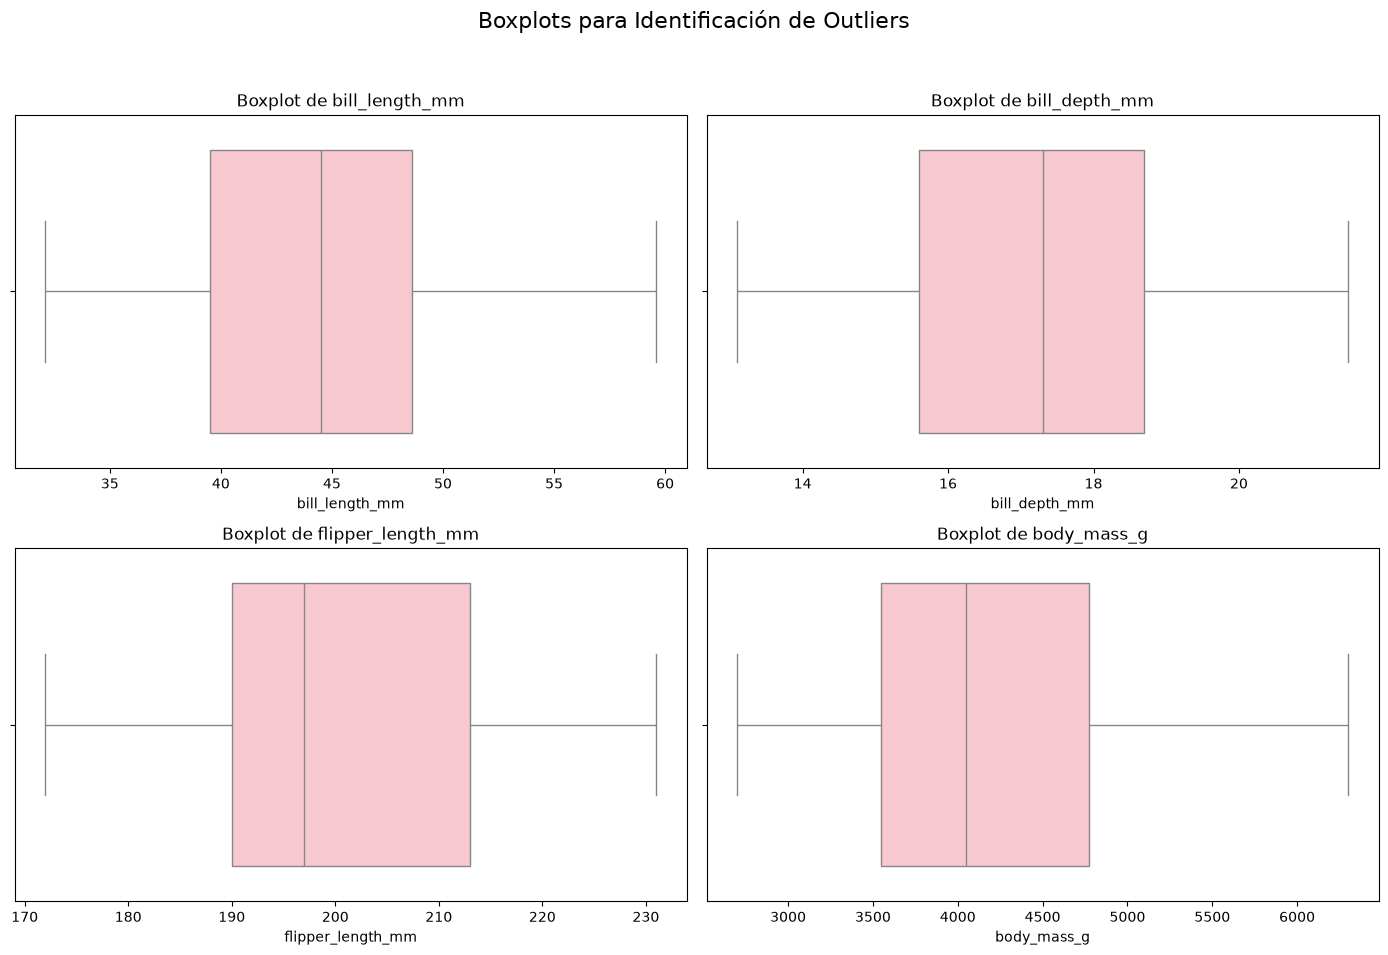

In [19]:
# Configuración de los Boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Boxplots para Identificación de Outliers', fontsize=16)

for i, col in enumerate(columnas_numericas):
    sns.boxplot(x=datos_penguins[col], ax=axes[i//2, i%2], color='pink')
    axes[i//2, i%2].set_title(f'Boxplot de {col}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

No vemos nada raro, por lo que pasemos a ver un poco las interacciones entre variables.